## PERFORMING EXPLORATORY DATA ANALYSIS(EDA) AND VISUALIZATION

#### **GOAL:**
* Performing EDA using pandas and required libraries
* Visualizing the results for better understanding using the seaborn,matplot libraries

**Important points:**
* First, import the required libraries to Perform EDA ,Analyzing and Visualizing the results like pandas,seaborn,matplot etc.,

### *IMPORTING LIBRARIES*

In [207]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')

### *UNDERSTANDING THE  DATASET* : **REMOTE JOBS DATASET**

* Load the Dataset and then Understand the dataset using pandas to know the basic information,shape(rows,columns),datatypes,descriptive summary etc.,
Skewness and Kurtosis.
* Extract all the ibnformation needed to understand the data completely.

In [208]:
def load_and_describe(file_name):

    try:
        df=pd.read_csv(file_name)

        '''DATA DESCRIPTION'''
        print('='*50,'Data Description:','='*50)
        
        print('\n','-'*10,'Dataset Head:','-'*10,'\n')
        print(df.head())
        
        print('\n','-'*10,'Basic Information:','-'*10,'\n')
        print(df.info())
        
        print('\n','-'*10,'Summary Statistics:','-'*10,'\n')
        print(df.describe())

        print('\n','-'*10,'Data Types:','-'*10,'\n')
        print(df.dtypes)
        
        print('\n','-'*10,'Skewness:','-'*10,'\n')
        print(df.skew(numeric_only=True))
        
        print('\n','-'*10,'Kurtosis:','-'*10,'\n')
        print(df.kurt(numeric_only=True))

        return df
        
    except Exception as e:
        print(f'error loading the data:{e}')
        return none 
    

### *DATA CLEANING AND PREPROCESSING*

* After Understanding the data completely now we have a complete information about the data.
* Now, We can Check for the Duplicates and if any we can drop them using pandas methods.
* Next, Check for the missing values in the data, if Present then impute them with mean,meadian,mode,or anything according to the column of the dataset.
* Then, Check for Outliers, if Present then treat the outliers by replacing them with mean nothing but Q2 as we done below.

In [209]:
def clean_data(df):

    '''"1.FIRST CONVERTING THE DATE POSTED COLUMN FROM OBJECT TO DATETIME'''
    
    # Convert 'date_posted' column to datetime
    print('\n','-'*10,'1.converting dateposted column from object to datetime:','-'*10,'\n')
    df['Date Posted'] = pd.to_datetime(df['Date Posted'], errors='coerce')

    print('After converting the Datatype of Date Posted column, Again checking the DataTypes of columns \n')
    print(df.dtypes)
    
    '''2.HANDLING MISSING VALUES,DUPLICATE VALUES AND OUTLIERS IN THE DATASET'''

    
    '''A.CHECKING FOR DUPLICATES AND DUPLICATE VALUE TREATMENT'''
    
    #duplicate values detection
    print('\n','-'*10,'2.checking for duplicate values:','-'*10,'\n')
    print(f'Duplicate Values:{df.duplicated().sum()}','\n')

    #duplicate values treatment by droping 
    df=df.drop_duplicates()

    print('\n',f'No Duplicates Present in this Dataset .Remaining rows :{len(df)} ','\n')


    
    '''B.CHECKING FOR MISSING VALUES AND MISSING VALUE TREATMENT'''

    #missing values detection in percentage
    print('\n','-'*10,'checking for missing values percentage:','-'*10,'\n')
    print(f'Missing Value percentage Before Imputing :','\n')
    print(f'{round(df.isnull().sum()/len(df) *100,2)}%')

    #Handling the missing values or imputing the missing values for location,minimum_salary and maximum_salary

    # Replace NaN values with 'World Wide' in the Location column
    df['Location'] = df['Location'].fillna('World Wide')

    # Impute Minimum Salary and Maximum Salary with their respective median values
    df['Minimum Salary (Rupees)'] = df['Minimum Salary (Rupees)'].fillna(df['Minimum Salary (Rupees)'].median())
    df['Maximum Salary (Rupees)'] = df['Maximum Salary (Rupees)'].fillna(df['Maximum Salary (Rupees)'].median())

    print('\n',f'Checking For Missing Value percentage After Imputing:','\n')
    print(f'{round(df.isnull().sum()/len(df) *100,2)}%')

    '''OUTLIER DETECTION AND TREATMENT'''

    #outlier detection
    print('\n','-'*10,'Outlier Analysis','-'*10,'\n')

    numeric_data=df.select_dtypes(include=np.number)

    for col in numeric_data.columns:
        Q1=df[col].quantile(0.25)
        Q2=df[col].quantile(0.5)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        LW=Q1-(1.5*IQR)
        UW=Q3+(1.5*IQR)
        outliers=((df[col] < LW) | (df[col] > UW))

        if outliers.sum() > 0:
            print(f'{col} has  {outliers.sum()/len(df)*100:.2f}% outliers ')
        else:
            print(f'{col} des not have any outliers ')

    #outlier treatment
    df.loc[(df[col] < LW) | (df[col] > UW),col]=Q2
    print('\n Outliers Treated Succesfully \n')

   
    return df
    

### *IDENTIFYING TRENDS*

* Now, We have the cleaned data ready to identify trends nothing but analyzing.
* Identifying the Number of Postings per Location using **Bar Plot**
* Identifying Distributions for minimum and maximum salary using **Histogram**
* Identifying the Number of Postings per Company using **Bar Plot**
* Identifying the Number of postings per date using **Bar Plot**
* Finally, Correlation Analysis of Numeric Columns using **Heatmap**

In [210]:
def identify_trends(df):
    
    '''IDENTIFYING TRENDS IN  DATA THROUGH VISUALS'''

    '''1. BAR PLOT - Jobs Posted per Location :Number of postings per location'''
    
    plt.figure(figsize=(9,10))

    # Count the number of job postings per location
    location_counts = df['Location'].value_counts()
    
    # Plotting the bar plot for companies
    plt.barh(location_counts.index, location_counts.values, color='blue')
    
    
    # Adding labels and title
    plt.ylabel("Location",fontsize=12)
    plt.xlabel("Number of Job Postings",fontsize=12)
    plt.title("Jobs Posted per Location",fontsize=14)
    
    # Display the plot
    plt.show()
        
    ''' 2.HISTOGRAM - Distributions for minimum and maximum salary '''
    
    plt.figure(figsize=(12, 6))

    #dividing the plots using subplots to see the distributions os maximim and minimum salaries
    plt.subplot(1, 2, 1)
    sns.histplot(df['Minimum Salary (Rupees)'], bins=20, color='skyblue', kde=True)

    # Adding labels and title
    plt.title("Distribution of Minimum Salary",fontsize=14)
    plt.xlabel("Minimum Salary (Rupees)",fontsize=12)
    plt.ylabel("Frequency",fontsize=12)
    
    plt.subplot(1, 2, 2)
    sns.histplot(df['Maximum Salary (Rupees)'], bins=20, color='lightgreen', kde=True)

    # Adding labels and title
    plt.title("Distribution of Maximum Salary",fontsize=14)
    plt.xlabel("Maximum Salary (Rupees)",fontsize=12)
    plt.ylabel("Frequency",fontsize=12)

    # Display the plot
    plt.tight_layout()
    plt.show()

    '''3. BAR PLOT - Jobs Posted per Company :Number of postings per Company'''
    
    plt.figure(figsize=(9, 15))
    
    # Count the number of job postings per company
    company_counts = df['Company'].value_counts()
    
    # Plotting the bar plot for companies
    plt.barh(company_counts.index, company_counts.values, color='blue')
    
    # Adding labels and title
    plt.ylabel("Company", fontsize=12)
    plt.xlabel("Number of Job Postings", fontsize=12)
    plt.title("Jobs Posted per Company", fontsize=14)
    
    # Display the plot
    plt.show()


    '''4. BAR PLOT - Jobs Posted per Date : Number of postings per date'''
    
    # Group by 'Date Posted' and count the number of job postings for each date
    date_posted_counts = df.groupby('Date Posted').size().reset_index(name='Job Postings')
    
    # Plotting a bar plot for the number of job postings per date
    plt.figure(figsize=(12, 6))
    plt.bar(date_posted_counts['Date Posted'], date_posted_counts['Job Postings'], color='teal')
    
    # Adding labels and title
    plt.xlabel("Date Posted", fontsize=12)
    plt.ylabel("Number of Job Postings", fontsize=12)
    plt.title("Number of Job Postings per Date", fontsize=14)
    plt.xticks(rotation=45)
    
    # Display the plot
    plt.show()

    ''' 5. Correlation Analysis'''
    # Compute correlation matrix
    correlation_matrix = df.corr(numeric_only=True)
    
    # Set up the matplotlib figure
    plt.figure(figsize=(12, 8))
    
    # Draw the heatmap
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title("Correlation Matrix Heatmap")
    plt.show()
    
    
        



### *GENERATING INSIGHTS*

* Analyzing the Insights from the data we have generated the visualizations.

In [211]:
def generate_insights():
    return '''
GENERATING INSIGHTS FROM DATA:

1.General Observations:
    ---> Job postings are widely distributed across many companies.
    ---> Most roles are remote or location-flexible.
    ---> Salaries span a wide range, but mid-tier compensation dominates.
    ---> The posting rate is steady, with roughly 1 new job posted each day over the data period.
 
2.Job Postings by Company:
    ---> A small number of companies (like Contra and Anchorage Digital) post multiple jobs, indicating active hiring.
    ---> Most companies post only one role, suggesting either selective hiring or single-position needs.
    ---> There’s a long tail of employers, pointing to broad market demand across different firms.

3.Job Postings by Location:
    ---> Most jobs are marked “World Wide” or “Remote”, highlighting the trend of global, flexible work arrangements.
    ---> Very few jobs are tied to specific cities—strong evidence of remote-first hiring cultures.
    ---> United States appears frequently, implying North America as a key hiring region, even for remote jobs.

4.Salary Distribution:
    ---> The most frequent minimum salary lies between ₹50,000–₹70,000 per month.
    ---> Most maximum salaries also cluster around ₹70,000–₹90,000 per month
    ---> Higher salaries are associated with fewer roles but likely indicate more senior or specialized positions.
    ---> Most salaries cluster between ₹40k and ₹110k, reflecting a range suitable for mid-level professionals.
    ---> There are a few outliers offering Very high salaries (₹150k+) which are rare, but represent premium opportunities.

5.Job Postings Over Time:
    ---> Jobs are posted consistently throughout April 2025.
    ---> No major spikes or dips—suggests organic growth or regular scraping/posting cycles.
    ---> Steady pace implies stable market conditions, not driven by seasonal or reactionary trends.

6.Salary vs Location Interaction:
    ---> Higher-paying jobs often align with worldwide or remote listings, suggesting global talent targeting.
    ---> Lower salaries are more likely in broadly remote or undefined markets, potentially reflecting early-stage companies or startups.
    ---> Specific-location jobs are few, but may align with mid-tier salary levels.

7.Correlation Analysis
    ---> Minimum and Maximum Salary are strongly positively correlated (correlation = 0.84).
    ---> This means when minimum salary increases, maximum salary usually increases too.
    ---> The correlation is high but not too high to cause multicollinearity issues (generally a concern when > 0.9).

## Summary of Key Insights:
    ---> Remote-first hiring dominates – most roles do not require a specific location.
    ---> Company activity is uneven – a few companies drive most of the job volume.
    ---> Salary range is broad, but mid-level compensation is most common.
    ---> Global access, small teams – many single-role postings reflect lean hiring.
    ---> The job market shows stable and consistent posting behavior '''



### *VISUALIZE RESULTS*

#### Now, We are Visualizing Results as Below
* Creating  **Line  Plot** Showing the Trends of Job Postings Over Time.
* Creating  **Bar Plot** Showing the Top 15 Job Postings per Locations.
* Creating **Box Plot** Showing the Salary Ranges of Minimum and Maximum Salaries.
* Creating  **Word cloud** for Common keywords in job titles
* Creating **Plot** for Trend chart to Show Jobs posted over days
* Creating **Plot** for Trend chart to Show Jobs posted over weeks

In [212]:
def visualize_results(data):
    
    '''GENERATE VISUALIZATION FOR DATASET FOR IN-DEPTH ANALYSIS'''
    
    # 1.JOB POSTING TRENDS OVER TIME (Line plot)
    job_postings_over_time = df.groupby(df['Date Posted'].dt.date).size()

    plt.figure(figsize=(10, 6))
    job_postings_over_time.plot(kind='line', color='green')
    plt.title('Jobs Posted Over Time',fontsize=14)
    plt.xlabel('Date',fontsize=12)
    plt.ylabel('Number of Job Postings',fontsize=12)
    plt.xticks(rotation=45)
    plt.show()


    #2.Bar Chart: Top 15 Job Locations
    plt.figure(figsize=(9,10))

    # Count the number of job postings per location
    location_counts = df['Location'].value_counts().sort_values(ascending=False).head(15)
    
    # Plotting the bar plot for companies
    plt.barh(location_counts.index, location_counts.values, color='blue')
    
    
    # Adding labels and title
    plt.ylabel("Location",fontsize=12)
    plt.xlabel("Number of Job Postings",fontsize=12)
    plt.title("Top 15 Locations per Job Postings",fontsize=14)
    
    # Display the plot
    plt.tight_layout()
    plt.show()


    #3. Box Plot: Salary Range
    # Drop rows where either salary is missing
    df_salary = df.dropna(subset=['Minimum Salary (Rupees)', 'Maximum Salary (Rupees)'])

    
    # Prepare the data for boxplot
    salary_data = [df_salary['Minimum Salary (Rupees)'], df_salary['Maximum Salary (Rupees)']]
    
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    plt.boxplot(salary_data, labels=['Minimum Salary (Rupees)', 'Maximum Salary (Rupees)'], vert=True)
    
    plt.ylabel('Salary', fontsize=12)
    plt.title('Distribution of Minimum and Maximum Salaries', fontsize=14)

    # Display the plot
    plt.grid(True) 
    plt.show()



    #4. Word cloud: Common keywords in job titles
  
    # Combine all job titles into a single string
    text = ' '.join(str(title).lower() for title in df['Job Title'] if pd.notnull(title))
    
    # Define stopwords (add your own if needed)
    stopwords = set(STOPWORDS)
    stopwords.update(stopwords)

    #Generate the Word Cloud
    wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords,
    collocations=False
    ).generate(text)

    # Plot the Word Cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Common Keywords in Job Titles', fontsize=14)

    # Display the plot
    plt.show()


    # 5.Trend chart: Jobs posted over days
    # Group by date and count job postings
    daily_counts = df['Date Posted'].value_counts().sort_index()
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-')
    
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Jobs Posted', fontsize=12)
    plt.title('Job Postings Per Day', fontsize=14)
    plt.xticks(rotation=45)

    # Display the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # 6. Trend chart: Jobs posted over weeks
    # Resample to weekly counts
    weekly_counts = df.set_index('Date Posted').resample('W')['Job Title'].count()
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(weekly_counts.index, weekly_counts.values, marker='o', linestyle='-')
    
    plt.xlabel('Week', fontsize=12)
    plt.ylabel('Number of Jobs Posted', fontsize=12)
    plt.title('Job Postings Per Week', fontsize=14)
    plt.xticks(rotation=45)

    # Display the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### *SUMMARIZING THE FINDINGS*

* Finally Summarizing the Data by calling all the Methods we created for Loading, Cleaning, Identifying Trends, Generating Insights
  and Visualizing Results.
  

In [213]:
def eda_function():
    
    file_name='Remoteok_Jobs.csv'

    print('='*10,'Understanding the Dataset','='*10,'\n')

    df=load_and_describe(file_name)
    if df is None:
        print(f' failed to load the {file_name} file')

    print('\n','='*10,'Data Cleaning and Preprocessing','='*10,'\n')
    cleaned_data=clean_data(df)
    # Converting cleaned data to csv
    cleaned_df.to_csv('Remote_Jobs_cleaned_data.csv', index=False)

    print('\n','='*10,'Identifying Trends','='*10,'\n')
    identify_trends(cleaned_data)

    print('\n','='*10,'Generating Insights','='*10,'\n')
    print(generate_insights())

    print('\n','='*10,'Visualizing Results','='*10,'\n')
    print(visualize_results(cleaned_data))

========== Understanding the Dataset ========== 

================================================== Data Description: ==================================================

 ---------- Dataset Head: ---------- 

                                      Job Title  \
0                           Product Manager VIP   
1                               Content Creator   
2                     Social Media Video Editor   
3  Itinerary Creator Turn Your Travels Into ome   
4                                Freight Broker   

                           Company Location  Minimum Salary (Rupees)  \
0                          Gate.io     APAC                      NaN   
1                           Contra      NaN                  70000.0   
2                           Contra      NaN                  70000.0   
3                          Worldee      NaN                  10000.0   
4  Givens Transportation Solutions      NaN                  10000.0   

   Maximum Salary (Rupees)          Date Posted  


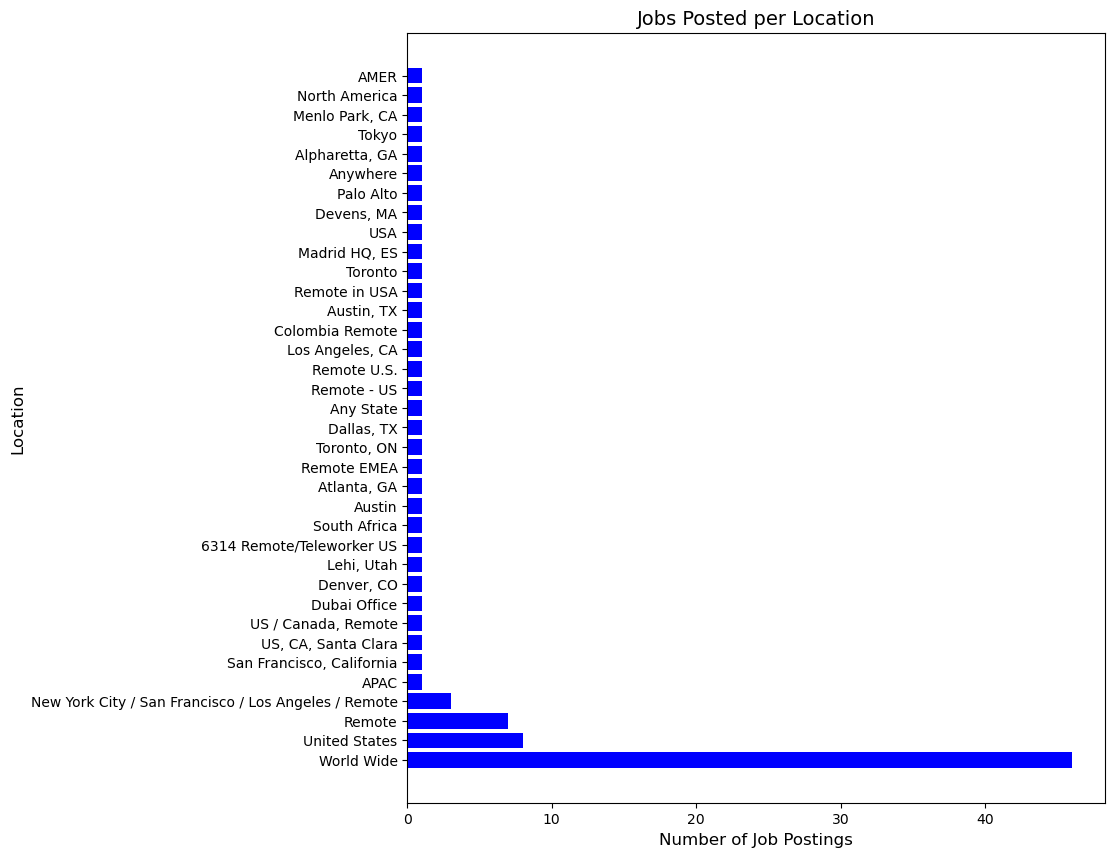

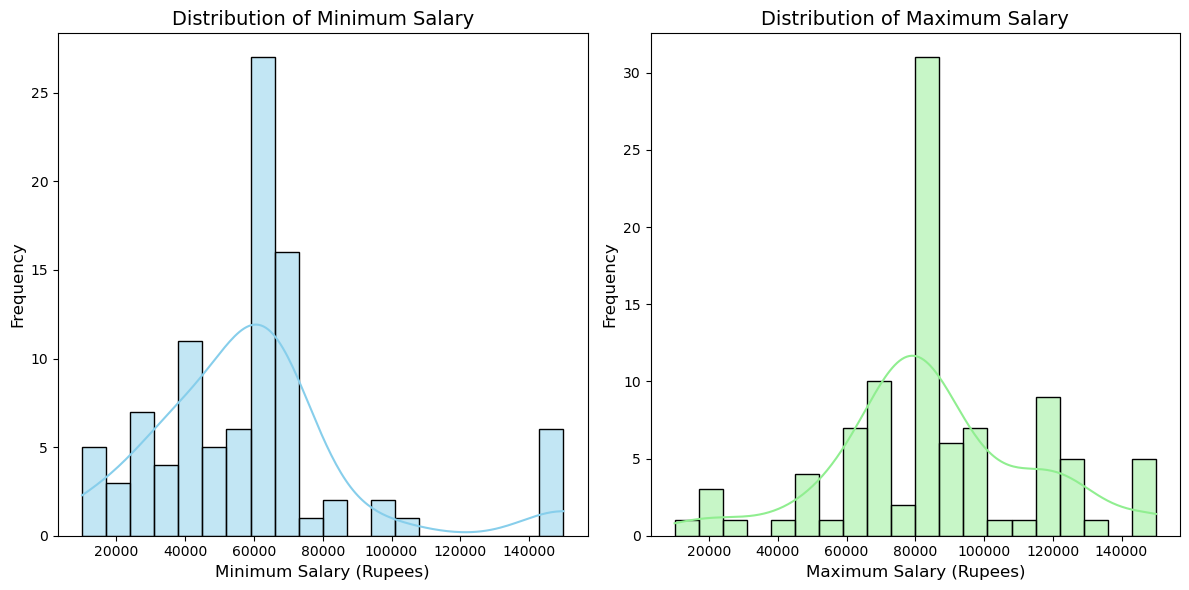

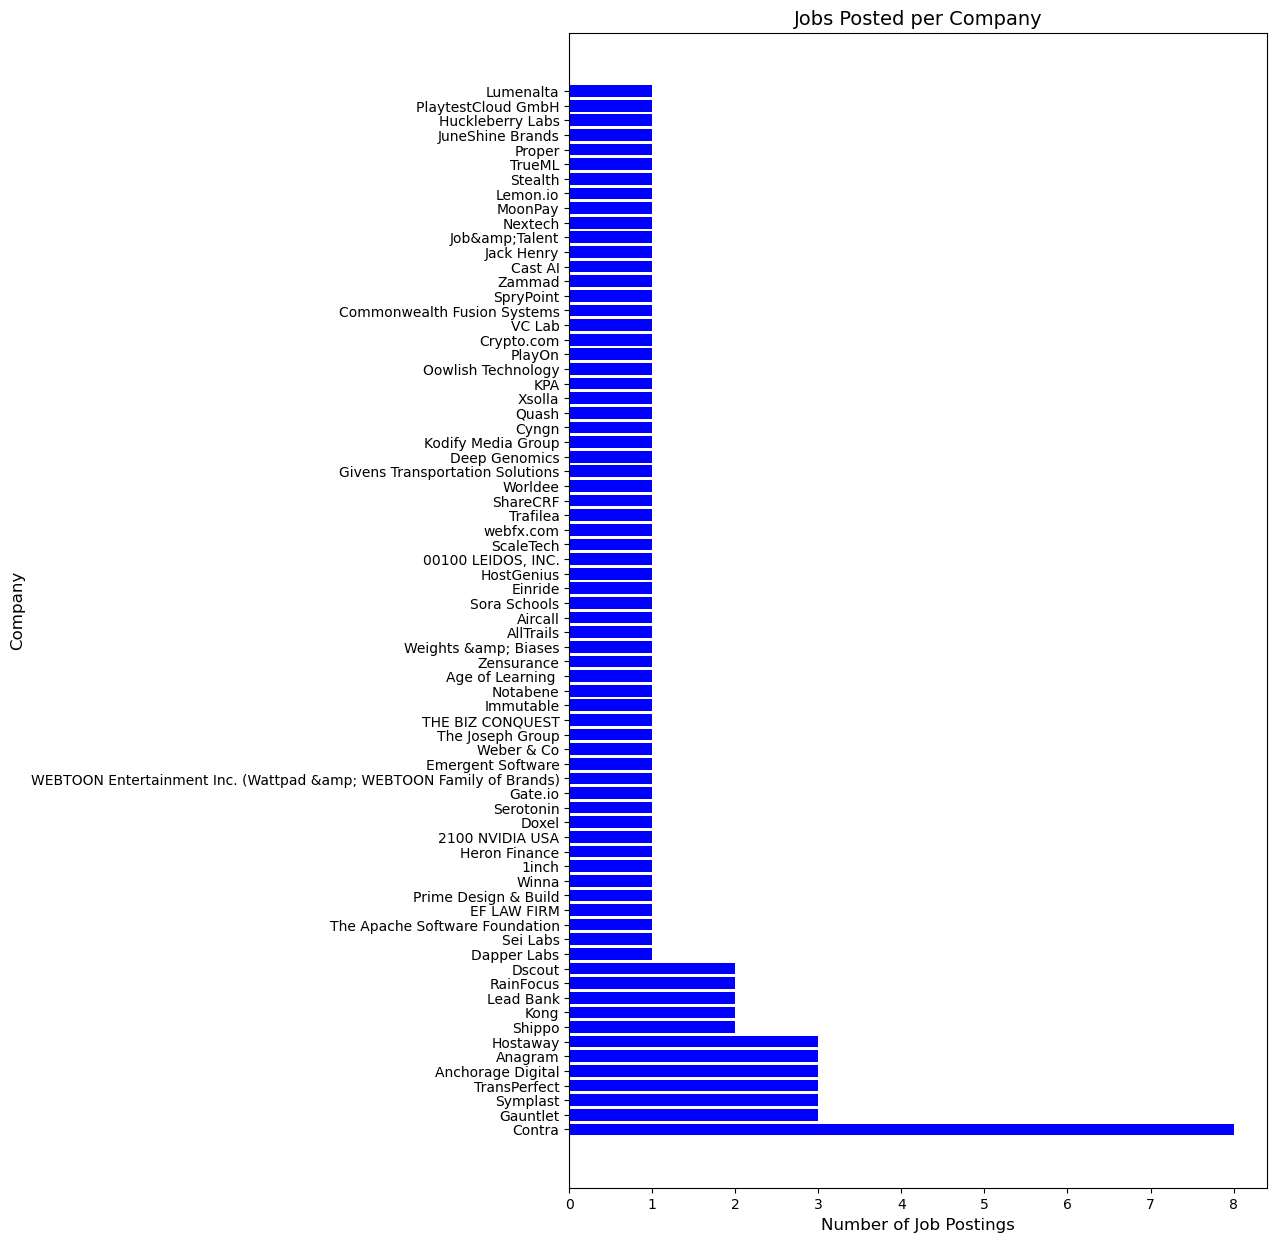

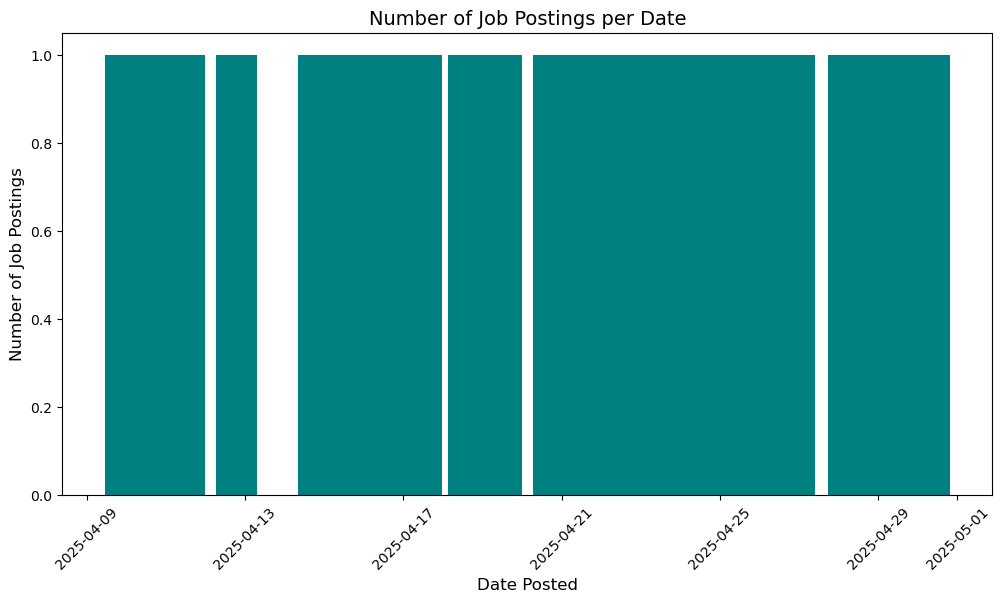

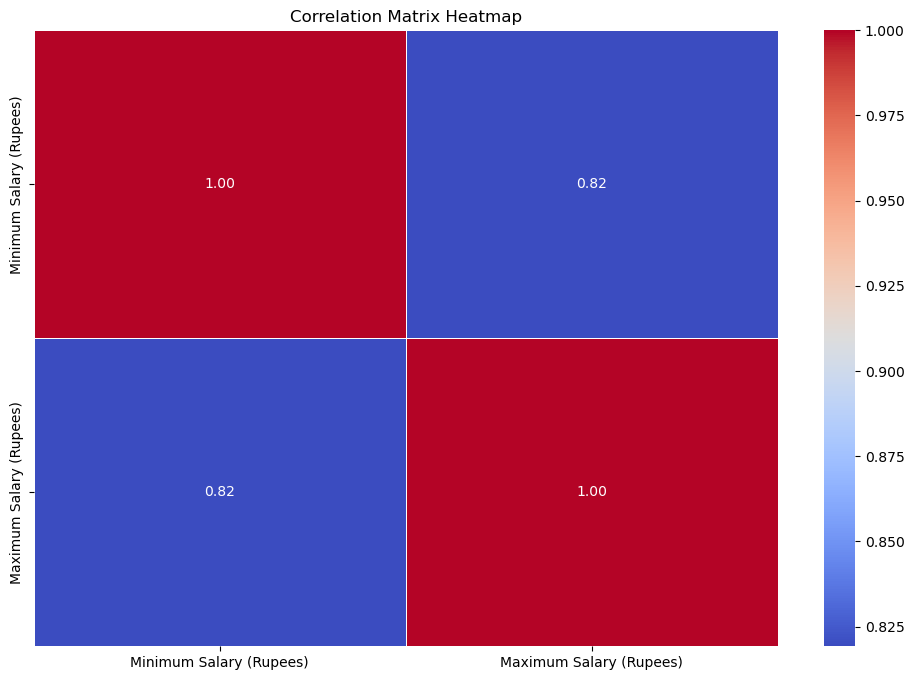


 ========== Generating Insights ========== 


GENERATING INSIGHTS FROM DATA:

1.General Observations:
    ---> Job postings are widely distributed across many companies.
    ---> Most roles are remote or location-flexible.
    ---> Salaries span a wide range, but mid-tier compensation dominates.
    ---> The posting rate is steady, with roughly 1 new job posted each day over the data period.
 
2.Job Postings by Company:
    ---> A small number of companies (like Contra and Anchorage Digital) post multiple jobs, indicating active hiring.
    ---> Most companies post only one role, suggesting either selective hiring or single-position needs.
    ---> There’s a long tail of employers, pointing to broad market demand across different firms.

3.Job Postings by Location:
    ---> Most jobs are marked “World Wide” or “Remote”, highlighting the trend of global, flexible work arrangements.
    ---> Very few jobs are tied to specific cities—strong evidence of remote-first hiring cultures.
    -

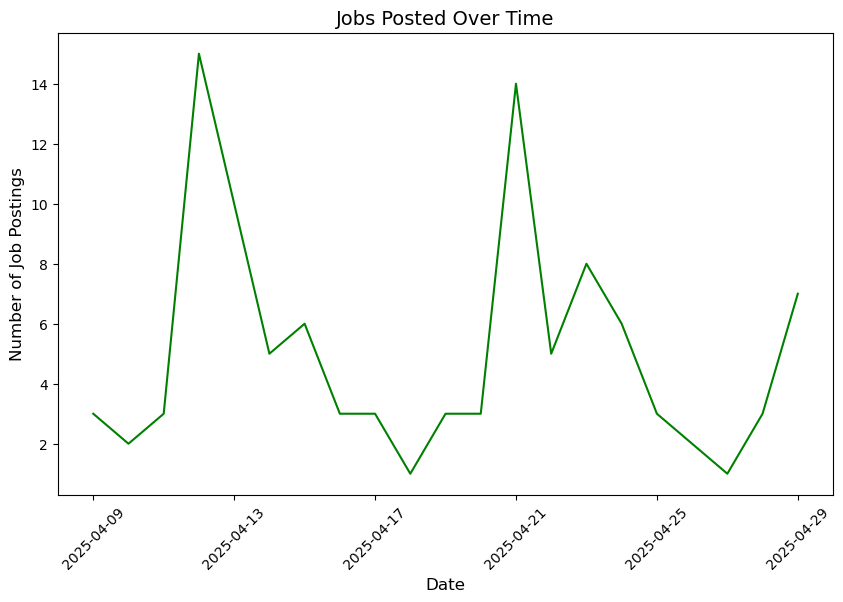

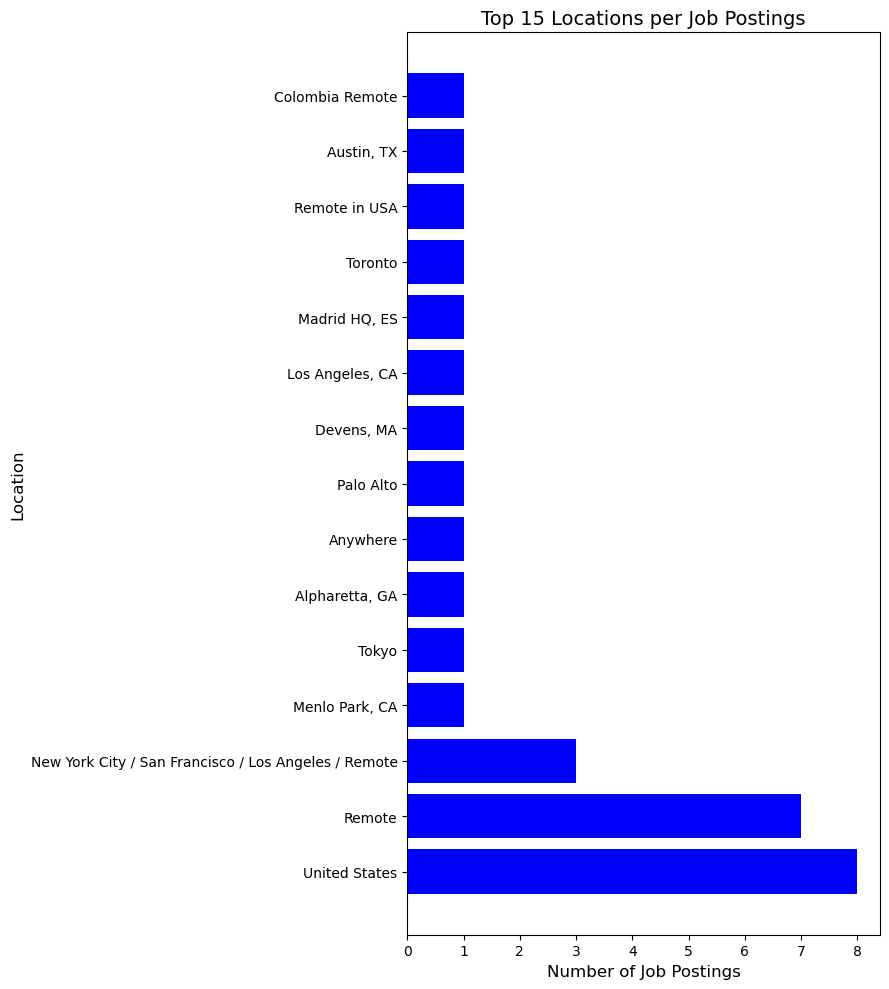

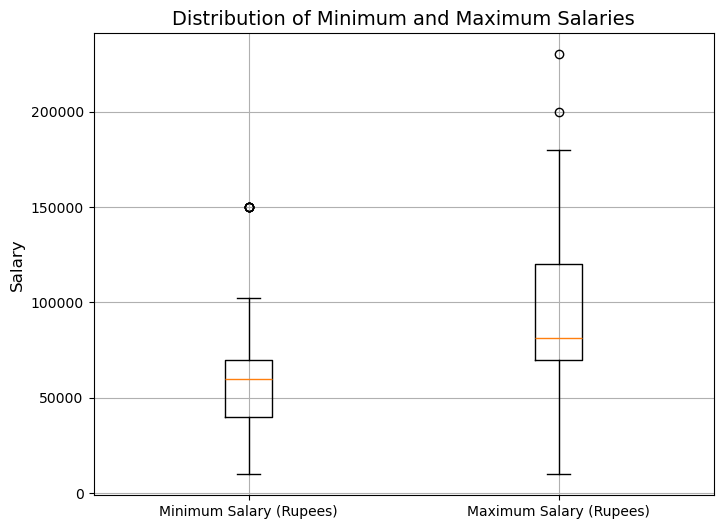

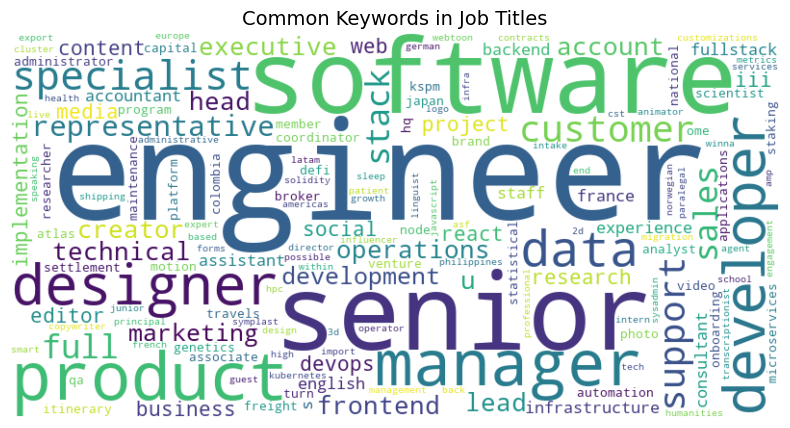

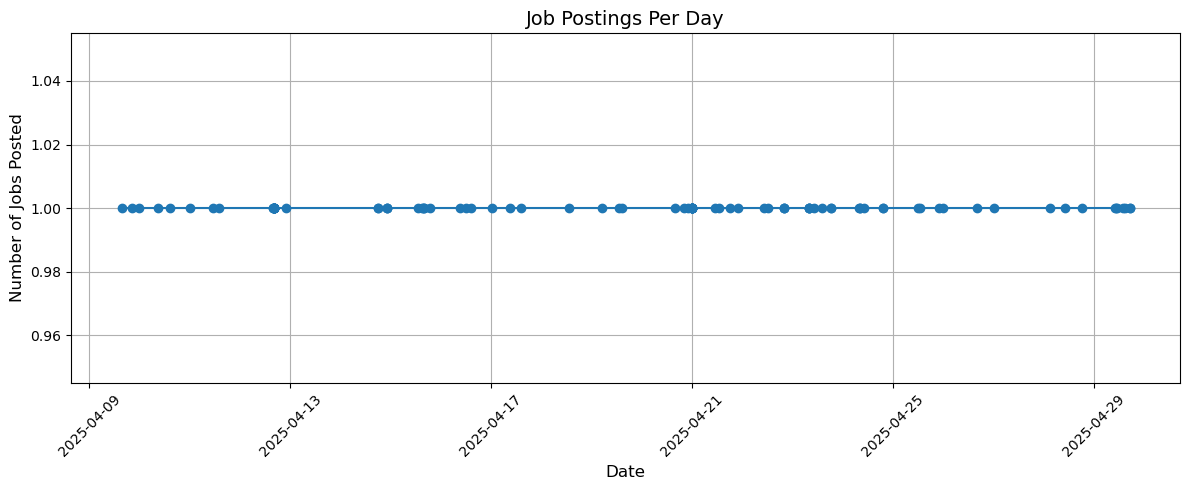

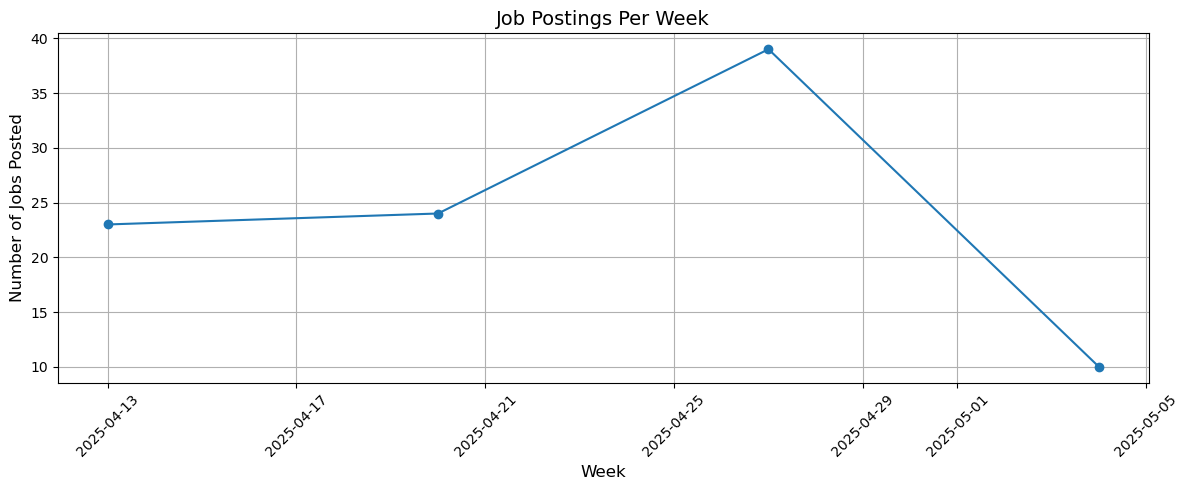

None


In [214]:
eda_function()